# Notebook 3 — SOLUTION

## Short version

**The data are pure i.i.d. noise -- there is no sequence.** The diagonal is
manufactured by the sort. Each neuron's "peak time" is just the location of the
largest bump in its own noise; ordering neurons by that quantity and then
displaying *the same data* guarantees a diagonal, because you arranged the peaks
along the diagonal by construction. This is the same circular-analysis error as
selecting on a statistic and then reporting it -- here applied to a whole
picture.

The test is simple: **choose the sort order on one set of trials and display an
independent set.** A real sequence survives; a sorting artifact vanishes.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

plt.rcParams['font.family']       = 'Arial'
plt.rcParams['font.sans-serif']   = ['Arial', 'DejaVu Sans']
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['pdf.fonttype']      = 42
plt.rcParams['ps.fonttype']       = 42

SMOOTH_SIGMA = 3.0   # temporal smoothing (bins)

def smooth(x):
    return gaussian_filter1d(x, SMOOTH_SIGMA, axis=1)

def zscore_rows(m):
    return (m - m.mean(1, keepdims=True)) / (m.std(1, keepdims=True) + 1e-9)

def show_seq(ax, mat, time, cmap='viridis', title=''):
    n = mat.shape[0]
    im = ax.imshow(zscore_rows(mat), aspect='auto', cmap=cmap,
                   extent=[time[0], time[-1], n, 0])
    ax.set_xlabel('time (s)'); ax.set_ylabel('neuron'); ax.set_title(title)
    return im


In [2]:
d = np.load('data/activity.npz')
activity = d['activity']          # (neuron, time, trial)
time = d['time']; dt = float(d['dt'])
n_neurons, n_time, n_trials = activity.shape
print(f'{n_neurons} neurons x {n_time} time bins x {n_trials} trials '
      f'({time[0]:.2f}-{time[-1]:.2f} s)')


100 neurons x 100 time bins x 10 trials (0.00-1.98 s)


In [3]:
# Reproduce the student's sorted plot.
X = smooth(activity.mean(axis=2))
order = np.argsort(X.argmax(axis=1))


## Evidence 1 — Cross-validate the sort (the key test)

Sort the neurons by peak time computed on **half** the trials, then display the
**other** half in that order. If the sequence were real, the held-out data would
still march down the diagonal. It doesn't -- it's back to noise.


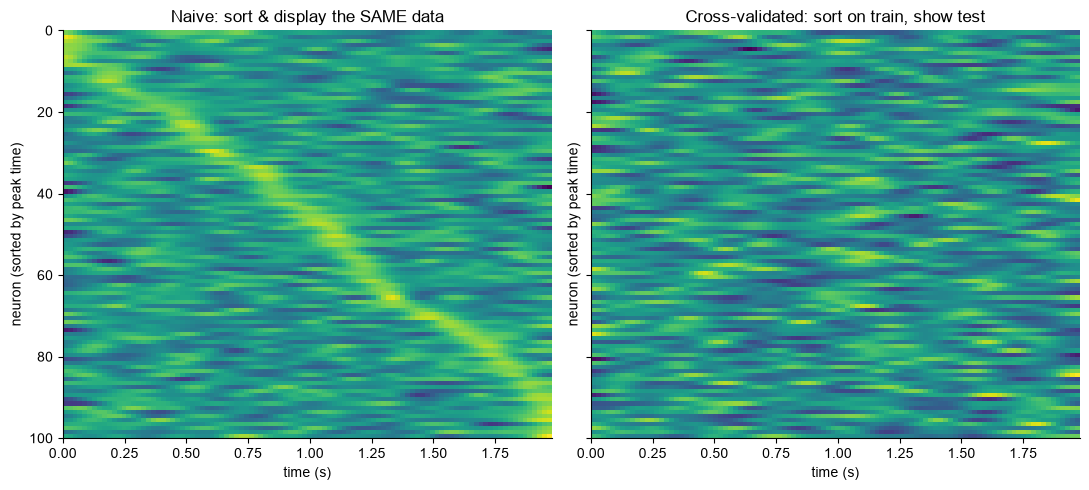

In [4]:
train = smooth(activity[:, :, 0::2].mean(axis=2))   # odd trials: choose the order
test  = smooth(activity[:, :, 1::2].mean(axis=2))   # even trials: display these
order_train = np.argsort(train.argmax(axis=1))

fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharey=True)
show_seq(axes[0], X[order], time, title='Naive: sort & display the SAME data')
show_seq(axes[1], test[order_train], time,
         title='Cross-validated: sort on train, show test')
for ax in axes:
    ax.set_ylabel('neuron (sorted by peak time)')
plt.tight_layout()
plt.show()


## Evidence 2 — Peak times are not reproducible across trials

If each neuron truly fired at a characteristic time, its peak time on one half
of the trials would predict its peak time on the other half (points on the
diagonal). Instead they are unrelated.


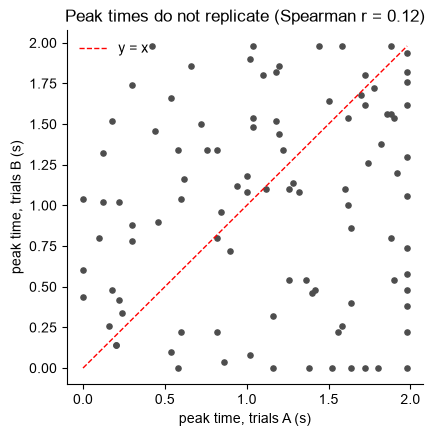

Spearman rank correlation of peak times across independent halves: 0.124
(A real sequence would give r near 1.)


In [5]:
from scipy.stats import spearmanr
pa = train.argmax(1) * dt
pb = test.argmax(1) * dt
rho = spearmanr(pa, pb).correlation

fig, ax = plt.subplots(figsize=(4.6, 4.6))
ax.scatter(pa, pb, s=14, color='0.3')
ax.plot([time[0], time[-1]], [time[0], time[-1]], 'r--', lw=1, label='y = x')
ax.set_xlabel('peak time, trials A (s)')
ax.set_ylabel('peak time, trials B (s)')
ax.set_title(f'Peak times do not replicate (Spearman r = {rho:.2f})')
ax.legend(frameon=False)
plt.show()
print(f'Spearman rank correlation of peak times across independent halves: {rho:.3f}')
print('(A real sequence would give r near 1.)')


## Evidence 3 — Sorting *any* noise produces the same diagonal

Generate a fresh, independent noise matrix and run the identical pipeline. The
diagonal is a property of peak-sorting, not of these particular neurons.


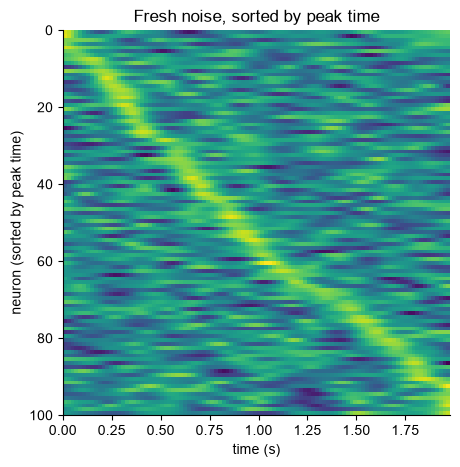

In [6]:
rng = np.random.default_rng(0)
fresh = smooth(rng.normal(0, 1, size=(n_neurons, n_time)))
fresh_order = np.argsort(fresh.argmax(1))

fig, ax = plt.subplots(figsize=(5, 5))
show_seq(ax, fresh[fresh_order], time, title='Fresh noise, sorted by peak time')
ax.set_ylabel('neuron (sorted by peak time)')
plt.show()


## Aside — the colormap oversells it, too

`jet` (and other rainbow maps) add sharp, non-uniform color transitions that the
eye reads as edges and bands. Here is the cross-validated (structureless) data in
a perceptually uniform map vs. jet: jet invents crispness that isn't in the data.
Prefer perceptually uniform colormaps (viridis, magma, ...).


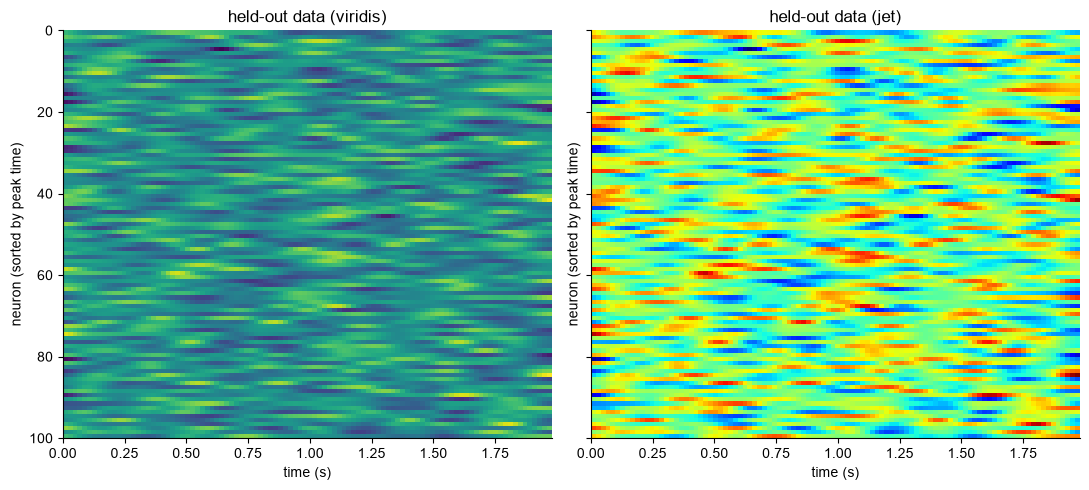

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharey=True)
show_seq(axes[0], test[order_train], time, cmap='viridis', title='held-out data (viridis)')
show_seq(axes[1], test[order_train], time, cmap='jet',     title='held-out data (jet)')
for ax in axes:
    ax.set_ylabel('neuron (sorted by peak time)')
plt.tight_layout()
plt.show()


## Ground truth


In [8]:
gt = np.load('data/ground_truth.npz', allow_pickle=True)
print('note:', str(gt['note']))


note: i.i.d. Gaussian noise for every neuron, time bin, and trial: no temporal sequence. Any diagonal after peak-sorting is a selection artifact.


## The lesson

- **Sorting neurons by a feature of the data, then displaying that same data,
  is circular.** Peak-sorting guarantees a diagonal even in pure noise -- the
  picture is arranged, not discovered.
- **Cross-validate sorted plots.** Choose the sort order (peak time, latency,
  cluster, weight, ...) on one set of trials and display an independent set. A
  real sequence survives; an artifact collapses. Equivalently, check that the
  sorting feature is reproducible across independent data.
- **This is not the same as Notebook 1.** There, sorting a heatmap by peak time
  revealed a *real* continuous structure that survives this test. The sort is a
  fine visualization -- the error is treating the sorted picture itself as
  evidence, without checking it holds out.
- **Mind the colormap.** Rainbow maps like jet manufacture apparent edges;
  perceptually uniform maps show the data as it is.
